In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import geopandas as gpd
from shapely.geometry import Point

# Exploration Data Analysis
1. Data Exploration

In [6]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the dataset
train_data = pd.read_csv('CSV_train.csv')

In [7]:
print(f"Dataset shape: {train_data.shape}")
print("\nSample data:")
print(train_data.head())

print("\nFeature statistics:")
print(train_data.describe().T)

print("\nData types:")
print(train_data.dtypes)


Dataset shape: (1048575, 29)

Sample data:
      WELL  DEPTH_MD        X_LOC      Y_LOC       Z_LOC         GROUP  \
0  15/9-13   494.528  437641.9688  6470972.5 -469.501831  NORDLAND GP.   
1  15/9-13   494.680  437641.9688  6470972.5 -469.653809  NORDLAND GP.   
2  15/9-13   494.832  437641.9688  6470972.5 -469.805786  NORDLAND GP.   
3  15/9-13   494.984  437641.9688  6470972.5 -469.957794  NORDLAND GP.   
4  15/9-13   495.136  437641.9688  6470972.5 -470.109772  NORDLAND GP.   

  FORMATION       CALI  RSHA      RMED  ...        ROP  DTS  DCAL      DRHO  \
0       NaN  19.480835   NaN  1.611410  ...  34.636410  NaN   NaN -0.574928   
1       NaN  19.468800   NaN  1.618070  ...  34.636410  NaN   NaN -0.570188   
2       NaN  19.468800   NaN  1.626459  ...  34.779556  NaN   NaN -0.574245   
3       NaN  19.459282   NaN  1.621594  ...  39.965164  NaN   NaN -0.586315   
4       NaN  19.453100   NaN  1.602679  ...  57.483765  NaN   NaN -0.597914   

   MUDWEIGHT  RMIC  ROPA  RXO  FORCE_


Missing values analysis:
                                   Missing Values  Percentage
SGR                                        985677   94.001574
RMIC                                       913036   87.073981
DTS                                        912421   87.015330
ROPA                                       902089   86.029993
DCAL                                       778296   74.224161
MUDWEIGHT                                  748117   71.346065
RXO                                        736465   70.234843
ROP                                        578569   55.176692
BS                                         471132   44.930692
RSHA                                       460853   43.950409
PEF                                        459442   43.815845
NPHI                                       378574   36.103664
SP                                         234986   22.410033
DRHO                                       166200   15.850082
RHOB                                       1

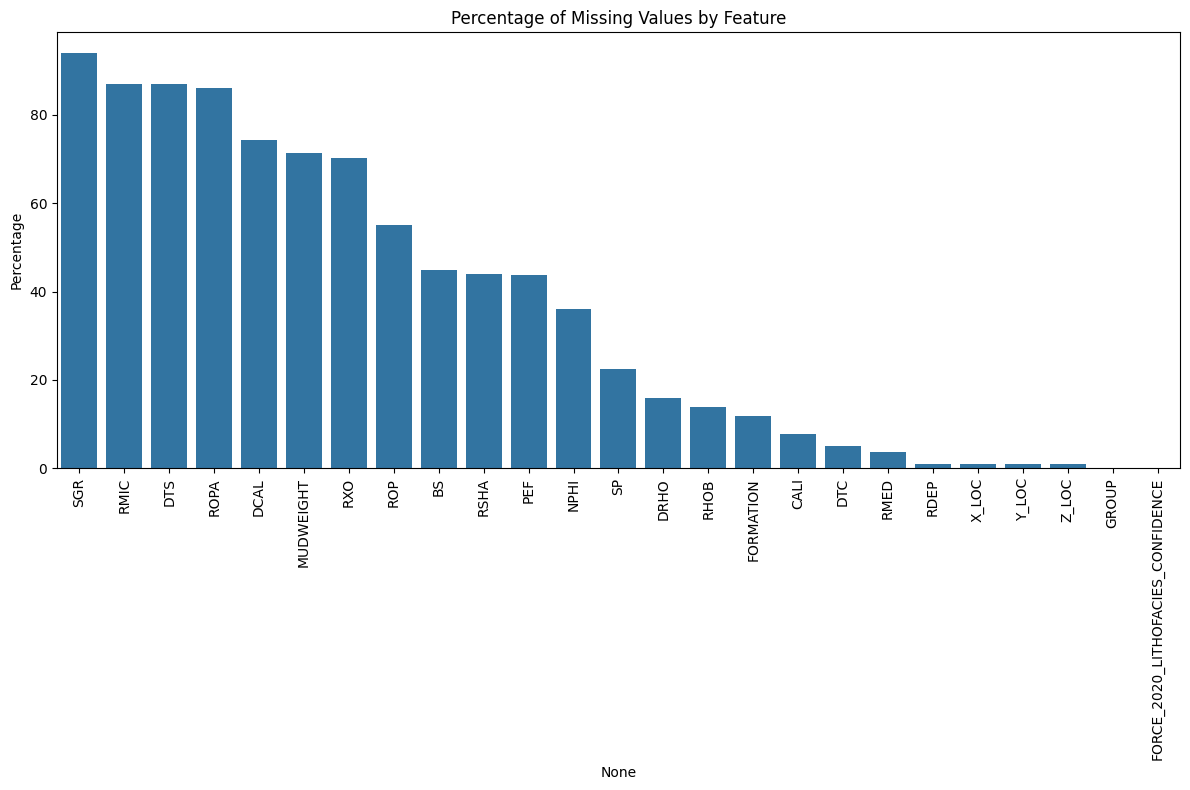

In [8]:
# Missing value analysis
missing_values = train_data.isnull().sum()
missing_percentage = (missing_values / len(train_data)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Percentage', ascending=False)
print("\nMissing values analysis:")
print(missing_df)

# Plot missing values
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=missing_df.index, y='Percentage', data=missing_df)
plt.title('Percentage of Missing Values by Feature')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('missing_values.png')
plt.show()


Number of unique wells: 86

Samples per well:
count       86.000000
mean     12192.732558
std       6800.399802
min       1734.000000
25%       6206.750000
50%      12534.000000
75%      17706.500000
max      25131.000000
dtype: float64


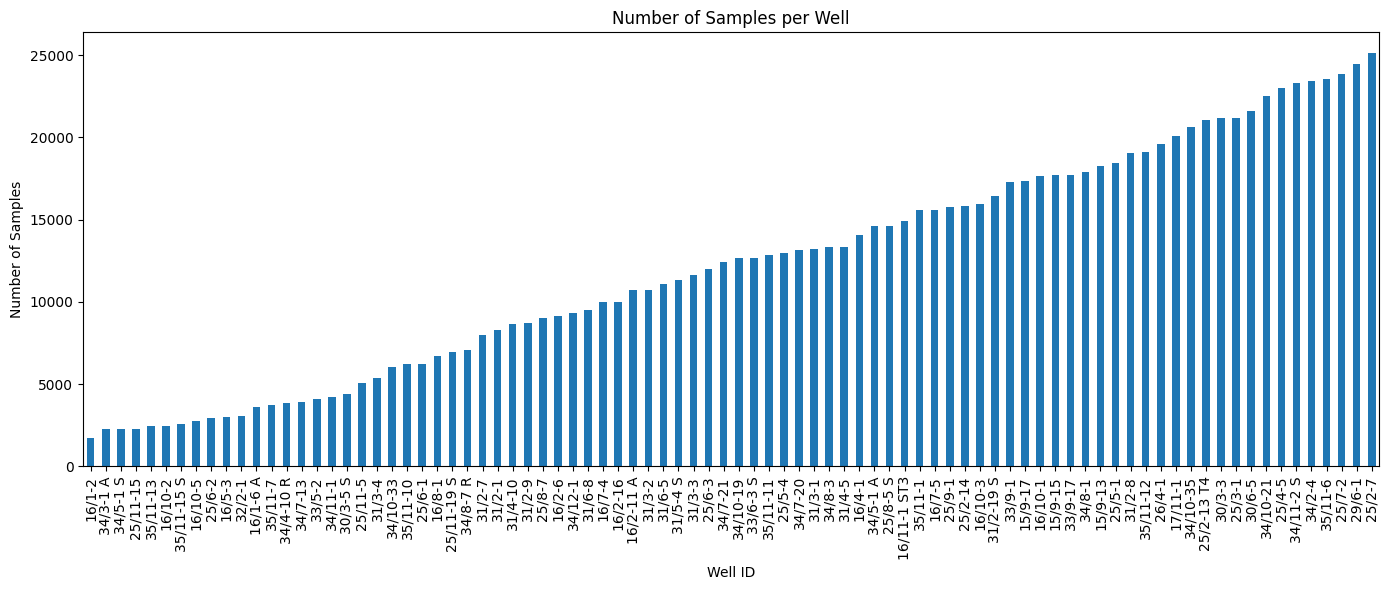

In [9]:
# Well distribution analysis
wells = train_data['WELL'].unique()
print(f"\nNumber of unique wells: {len(wells)}")

well_counts = train_data.groupby('WELL').size()
print("\nSamples per well:")
print(well_counts.describe())

plt.figure(figsize=(14, 6))
well_counts.sort_values().plot(kind='bar')
plt.title('Number of Samples per Well')
plt.xlabel('Well ID')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('well_distribution.png')
plt.show()

2. LITHOLOGY CLASSIFICATION


Lithology class distribution:
Shale              640621
Sandstone          153375
Sandstone/Shale    134172
Limestone           51959
Marl                30116
Tuff                15124
Chalk                8472
Halite               8213
Coal                 3666
Dolomite             1669
Anhydrite            1085
Basement              103
Name: LITHOLOGY_LABEL, dtype: int64


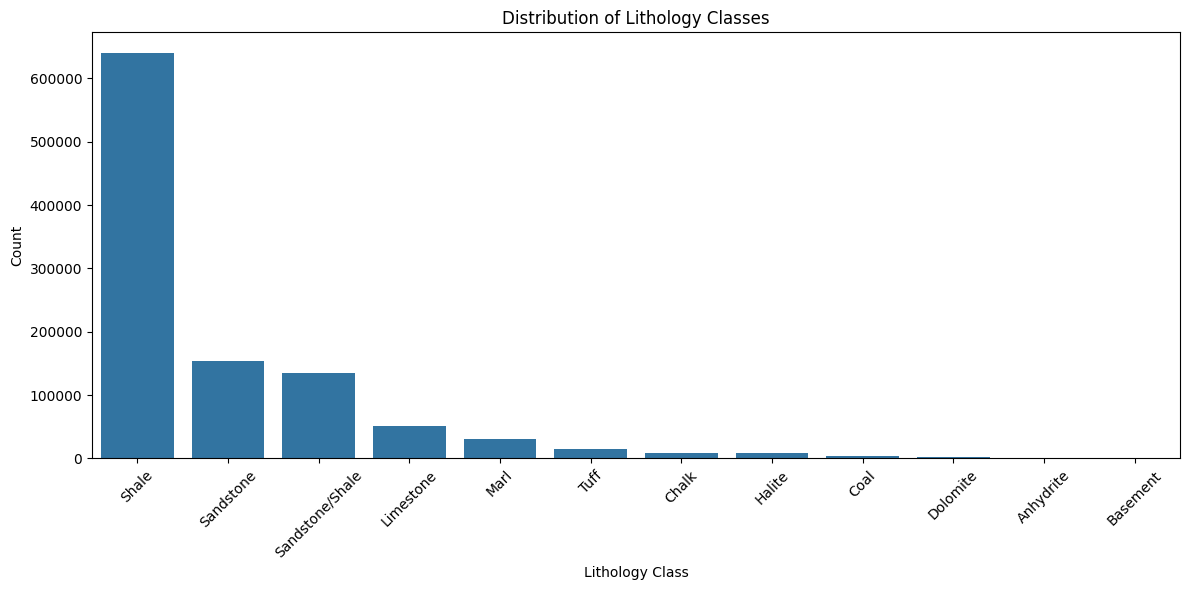

In [6]:
# Define the lithology classes
lithology_keys = {
    30000: 'Sandstone',
    65030: 'Sandstone/Shale',
    65000: 'Shale',
    80000: 'Marl',
    74000: 'Dolomite',
    70000: 'Limestone',
    70032: 'Chalk',
    88000: 'Halite',
    86000: 'Anhydrite',
    99000: 'Tuff',
    90000: 'Coal',
    93000: 'Basement'
}

# Create lithology label column
train_data['LITHOLOGY_LABEL'] = train_data['FORCE_2020_LITHOFACIES_LITHOLOGY'].map(lithology_keys)

# Display lithology distribution
lithology_counts = train_data['LITHOLOGY_LABEL'].value_counts()
print("\nLithology class distribution:")
print(lithology_counts)

# Plot lithology distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=lithology_counts.index, y=lithology_counts.values)
plt.title('Distribution of Lithology Classes')
plt.xlabel('Lithology Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('lithology_distribution.png')
plt.show()


Class imbalance ratio (max/min): 6219.62


<Figure size 1400x800 with 0 Axes>

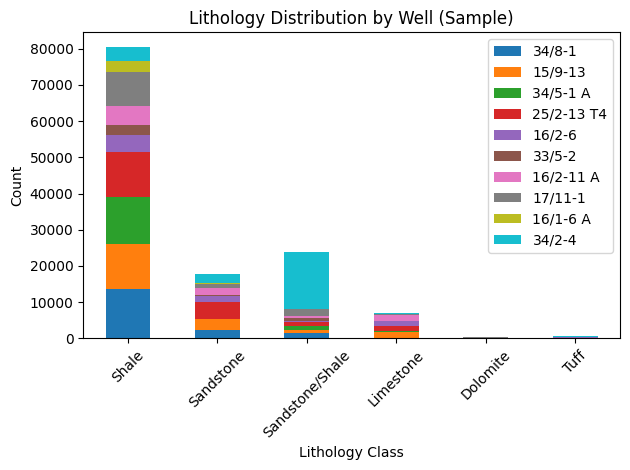

In [7]:
# Calculate class imbalance ratio
imbalance_ratio = lithology_counts.max() / lithology_counts.min()
print(f"\nClass imbalance ratio (max/min): {imbalance_ratio:.2f}")

# Plot lithology distribution by well (for a sample of wells if there are many)
sample_wells = np.random.choice(wells, min(10, len(wells)), replace=False)
well_litho_df = pd.DataFrame()

for well in sample_wells:
    well_data = train_data[train_data['WELL'] == well]['LITHOLOGY_LABEL'].value_counts()
    well_litho_df[well] = well_data

plt.figure(figsize=(14, 8))
well_litho_df.plot(kind='bar', stacked=True)
plt.title('Lithology Distribution by Well (Sample)')
plt.xlabel('Lithology Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('well_lithology_distribution.png')
plt.show()

# Data Preprocessing 

3. FEATURE ENGINEERING & SELECTION

In [8]:
# 1. Drop high-cardinality categorical features for now
train_data = train_data.drop(columns=['GROUP', 'FORMATION'])

# 2. Create depth-based features
if 'Z_LOC' in train_data.columns:
    # Calculate rate of change features for depth
    train_data['DEPTH_DIFF'] = train_data.groupby('WELL')['Z_LOC'].diff()
    
    # Create depth bin features
    train_data['DEPTH_BIN'] = pd.qcut(train_data['Z_LOC'], 10, labels=False)

# 3. Create log-based and ratio features (useful for lithology)
if all(col in train_data.columns for col in ['GR', 'NPHI', 'RHOB']):
    # Neutron-density separation (useful for lithology identification)
    train_data['NPHI_RHOB_DIFF'] = train_data['NPHI'] - train_data['RHOB']

if all(col in train_data.columns for col in ['GR', 'RDEP']):
    # Gamma ray to resistivity ratio
    train_data['GR_RDEP_RATIO'] = train_data['GR'] / train_data['RDEP'].replace(0, np.nan)

4. HANDLING MISSING VALUES

In [9]:
# 1. Remove features with too many missing values
missing_threshold = 0.7
high_missing_cols = missing_df[missing_df['Percentage'] > missing_threshold * 100].index.tolist()
print(f"\nRemoving {len(high_missing_cols)} features with >{missing_threshold*100}% missing values")
train_data = train_data.drop(columns=high_missing_cols)

# 2. Impute missing values using more sophisticated approaches
# Get numeric columns
numeric_cols = train_data.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'FORCE_2020_LITHOFACIES_LITHOLOGY']

# Use KNN imputation within each well for well logs (which should respect spatial relationships)
print("\nImputing missing values using KNN within each well...")
for well in wells:
    well_mask = train_data['WELL'] == well
    well_data = train_data.loc[well_mask, numeric_cols]
    
    # Only impute if there's sufficient data in this well
    if len(well_data) > 5 and well_data.isnull().sum().max() < len(well_data) * 0.5:
        imputer = KNNImputer(n_neighbors=5)
        train_data.loc[well_mask, numeric_cols] = imputer.fit_transform(well_data)

# For any remaining NaN values, use median imputation as it's more robust than mean
print("Imputing remaining missing values with column medians...")
imputer = SimpleImputer(strategy='median')
train_data[numeric_cols] = imputer.fit_transform(train_data[numeric_cols])


Removing 7 features with >70.0% missing values

Imputing missing values using KNN within each well...
Imputing remaining missing values with column medians...


5. FEATURE SCALING

In [10]:
# Use RobustScaler instead of StandardScaler for well log data (less sensitive to outliers)
print("\nScaling numerical features using RobustScaler...")
scaler = RobustScaler()
train_data[numeric_cols] = scaler.fit_transform(train_data[numeric_cols])

# Save the scaler for later use
import pickle
with open('robust_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


Scaling numerical features using RobustScaler...


6. TRAIN-TEST SPLIT

In [12]:
# We'll use GroupKFold for splitting to ensure no well data leakage between train/test
# This is critical for well log data to avoid spatial autocorrelation bias

# Save well IDs before dropping
well_ids = train_data['WELL'].copy()

# Drop WELL column as it's not a feature for the model
X = train_data.drop(columns=['WELL', 'LITHOLOGY_LABEL', 'FORCE_2020_LITHOFACIES_LITHOLOGY'])
y = train_data['LITHOLOGY_LABEL']

# Encode the target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save the label encoder for later use
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Create mapping dictionary for reference
label_map = {i: label for i, label in enumerate(label_encoder.classes_)}
print("\nEncoded labels mapping:")
for i, label in label_map.items():
    print(f"{i}: {label}")

# Split preserving well groups (this is very important for geological data)
print("\nPerforming group-based train-test split by well...")
gkf = GroupKFold(n_splits=5)
train_idx, test_idx = next(gkf.split(X, y_encoded, groups=well_ids))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
well_train, well_test = well_ids.iloc[train_idx], well_ids.iloc[test_idx]

# Get a validation set from the training set, still preserving well groups
train_idx, val_idx = next(gkf.split(X_train, y_train, groups=well_train))

X_train_final, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
y_train_final, y_val = y_train[train_idx], y_train[val_idx]

print(f"\nTraining set shape: {X_train_final.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

# Check wells distribution in train/val/test
train_wells = well_train.iloc[train_idx].unique()
val_wells = well_train.iloc[val_idx].unique()
test_wells = well_test.unique()

print(f"\nNumber of wells in training set: {len(train_wells)}")
print(f"Number of wells in validation set: {len(val_wells)}")
print(f"Number of wells in test set: {len(test_wells)}")

# Verify no wells are shared between splits
assert len(np.intersect1d(train_wells, val_wells)) == 0, "Wells are shared between train and val!"
assert len(np.intersect1d(train_wells, test_wells)) == 0, "Wells are shared between train and test!"
assert len(np.intersect1d(val_wells, test_wells)) == 0, "Wells are shared between val and test!"

# Check class distribution in each split
print("\nClass distribution in training set:")
print(pd.Series(y_train_final).value_counts().sort_index().map(label_map))

print("\nClass distribution in validation set:")
print(pd.Series(y_val).value_counts().sort_index().map(label_map))

print("\nClass distribution in test set:")
print(pd.Series(y_test).value_counts().sort_index().map(label_map))


Encoded labels mapping:
0: Anhydrite
1: Basement
2: Chalk
3: Coal
4: Dolomite
5: Halite
6: Limestone
7: Marl
8: Sandstone
9: Sandstone/Shale
10: Shale
11: Tuff

Performing group-based train-test split by well...

Training set shape: (670814, 22)
Validation set shape: (168371, 22)
Test set shape: (209390, 22)

Number of wells in training set: 55
Number of wells in validation set: 14
Number of wells in test set: 17

Class distribution in training set:
0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
dtype: object

Class distribution in validation set:
0     Halite
2        NaN
3        NaN
4        NaN
6        NaN
7        NaN
8        NaN
9        NaN
10       NaN
11       NaN
dtype: object

Class distribution in test set:
0     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
dtype: object


7. HANDLING CLASS IMBALANCE

In [13]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available.")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("❌ GPU is not available.")


✅ GPU is available.
Using GPU: Tesla T4


In [14]:
print("\nHandling class imbalance with SMOTETomek...")
# Using SMOTETomek - combination of oversampling and undersampling
smote_tomek = SMOTETomek(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_final, y_train_final)

print(f"Shape after resampling: {X_train_resampled.shape}")
print("\nClass distribution after resampling:")
print(pd.Series(y_train_resampled).value_counts().sort_index().map(label_map))

# Save the processed datasets
print("\nSaving processed datasets...")
with open('lithology_data_processed.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train_resampled,
        'y_train': y_train_resampled,
        'X_val': X_val,
        'y_val': y_val,
        'X_test': X_test,
        'y_test': y_test,
        'feature_names': X.columns.tolist(),
        'label_map': label_map,
        'train_wells': train_wells,
        'val_wells': val_wells,
        'test_wells': test_wells
    }, f)

print("Preprocessing complete!")


Handling class imbalance with SMOTETomek...


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import numpy as np

# ✅ Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 🎯 Hyperparameters
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 0.001
NUM_CLASSES = len(np.unique(y_train_resampled))

# ✅ Preprocessing: Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ✅ Reshape to [samples, channels, length] for 1D CNN
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# ✅ DataLoader
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=BATCH_SIZE)

# ✅ 1D CNN Model
class CNN1D(nn.Module):
    def __init__(self, input_length, num_classes):
        super(CNN1D, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear((input_length // 2) * 128, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))      # [B, 64, L]
        x = self.pool(F.relu(self.conv2(x)))  # [B, 128, L//2]
        x = self.dropout(x)
        x = x.view(x.size(0), -1)      # Flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# ✅ Initialize model
input_length = X_train_tensor.shape[2]
model = CNN1D(input_length=input_length, num_classes=NUM_CLASSES).to(device)

# ✅ Optimizer and Loss
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ✅ Training loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.4f}")

# ✅ Validation accuracy
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

print(f"\nValidation Accuracy: {correct/total:.2%}")


Using device: cuda
Epoch 1/20, Loss: 0.2339
Epoch 2/20, Loss: 0.1573
Epoch 3/20, Loss: 0.1402
Epoch 4/20, Loss: 0.1302
Epoch 5/20, Loss: 0.1235
Epoch 6/20, Loss: 0.1191
Epoch 7/20, Loss: 0.1151
Epoch 8/20, Loss: 0.1125
Epoch 9/20, Loss: 0.1099
Epoch 10/20, Loss: 0.1078
Epoch 11/20, Loss: 0.1059
Epoch 12/20, Loss: 0.1046
Epoch 13/20, Loss: 0.1032
Epoch 14/20, Loss: 0.1018
Epoch 15/20, Loss: 0.1007
Epoch 16/20, Loss: 0.0996
Epoch 17/20, Loss: 0.0987
Epoch 18/20, Loss: 0.0978
Epoch 19/20, Loss: 0.0970
Epoch 20/20, Loss: 0.0964

Validation Accuracy: 61.34%


In [17]:
from sklearn.metrics import classification_report, f1_score, recall_score

# ✅ Evaluate on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# ✅ Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# ✅ F1-score per class
f1_per_class = f1_score(all_labels, all_preds, average=None)
print("\nF1-score per class:")
for i, f1 in enumerate(f1_per_class):
    print(f"Class {i}: {f1:.4f}")

# ✅ Recall per class
recall_per_class = recall_score(all_labels, all_preds, average=None)
print("\nRecall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i}: {r:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0     0.9874    0.5567    0.7120       282
           2     0.9168    0.5380    0.6781      2500
           3     0.2855    0.7057    0.4065      1135
           4     0.0018    0.0033    0.0023       301
           5     0.0000    0.0000    0.0000      4294
           6     0.2863    0.6344    0.3946     11642
           7     0.2815    0.3802    0.3235      6496
           8     0.5785    0.3847    0.4621     31778
           9     0.1418    0.2984    0.1922     15795
          10     0.8558    0.7290    0.7873    133308
          11     0.5722    0.5842    0.5781      1859

    accuracy                         0.6082    209390
   macro avg     0.4461    0.4377    0.4124    209390
weighted avg     0.6869    0.6082    0.6342    209390


F1-score per class:
Class 0: 0.7120
Class 1: 0.6781
Class 2: 0.4065
Class 3: 0.0023
Class 4: 0.0000
Class 5: 0.3946
Class 6: 0.3235
Class 7: 0.4621
Class 8: 0.192

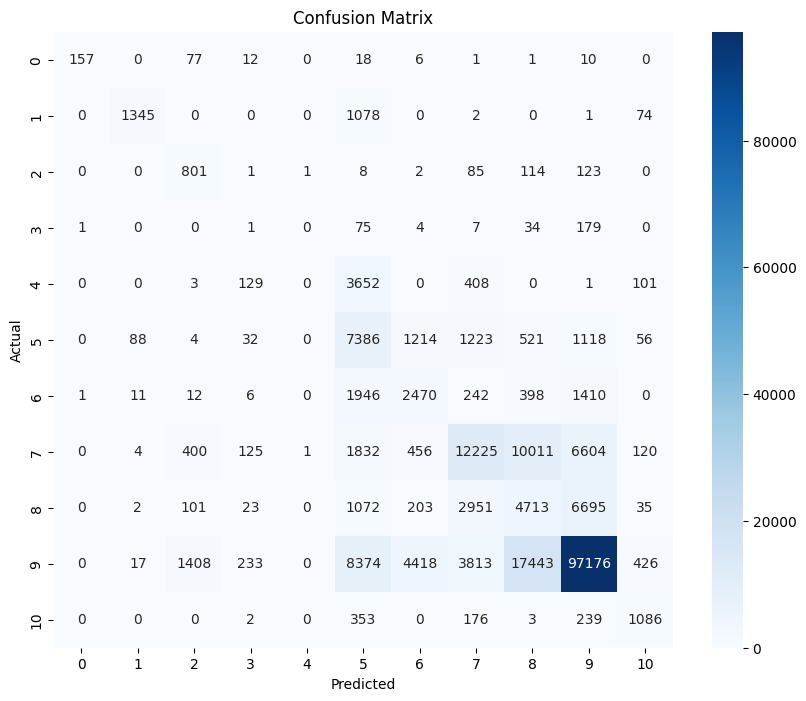

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
import collections
print(collections.Counter(y_train_resampled))
print(collections.Counter(y_test))

Counter({1: 403816, 2: 403815, 0: 403814, 11: 403810, 5: 403807, 4: 403804, 3: 403718, 7: 403557, 6: 403378, 8: 403018, 9: 402164, 10: 401635})
Counter({10: 133308, 8: 31778, 9: 15795, 6: 11642, 7: 6496, 5: 4294, 2: 2500, 11: 1859, 3: 1135, 4: 301, 0: 282})



F1-score per class (Random Forest):
Class 0: 0.0000
Class 1: 0.4066
Class 2: 0.5474
Class 3: 0.0000
Class 4: 0.0000
Class 5: 0.4733
Class 6: 0.1308
Class 7: 0.6851
Class 8: 0.1927
Class 9: 0.8543
Class 10: 0.6752

Recall per class (Random Forest):
Class 0: 0.0000
Class 1: 0.2552
Class 2: 0.6176
Class 3: 0.0000
Class 4: 0.0000
Class 5: 0.7744
Class 6: 0.0756
Class 7: 0.6550
Class 8: 0.2177
Class 9: 0.8408
Class 10: 0.6417


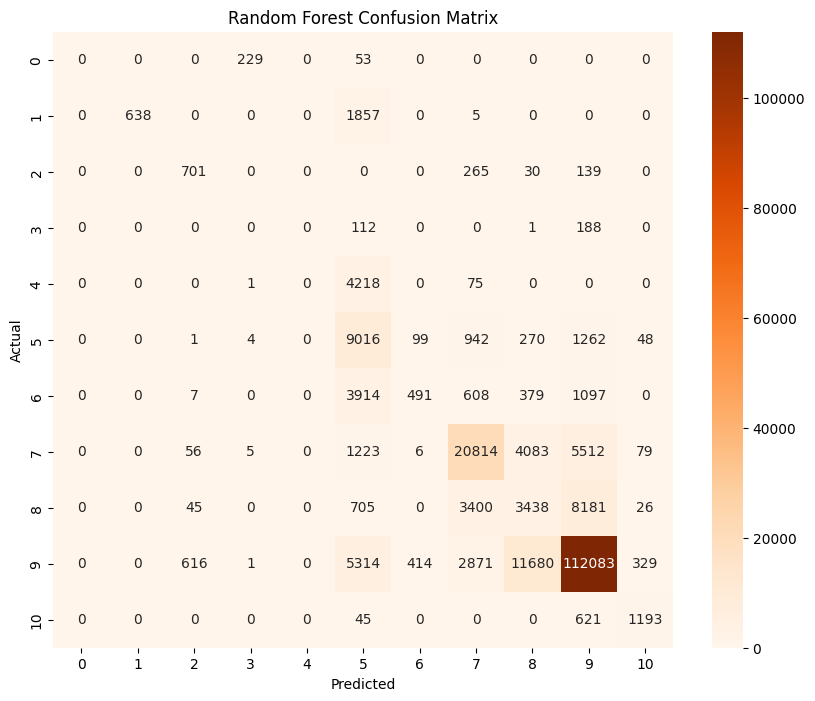

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Flatten input (hapus dimensi channel)
X_train_rf = X_train_scaled
X_test_rf = X_test_scaled

# ✅ Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_rf, y_train_resampled)

# ✅ Predict & Evaluate
y_pred_rf = rf_clf.predict(X_test_rf)

print("\n🎯 Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, digits=4))

# ✅ F1 & Recall per class
f1_per_class = f1_score(y_test, y_pred_rf, average=None)
recall_per_class = recall_score(y_test, y_pred_rf, average=None)

print("\nF1-score per class (Random Forest):")
for i, f1 in enumerate(f1_per_class):
    print(f"Class {i}: {f1:.4f}")

print("\nRecall per class (Random Forest):")
for i, r in enumerate(recall_per_class):
    print(f"Class {i}: {r:.4f}")

# ✅ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
from sklearn.metrics import accuracy_score

# 🎯 Akurasi Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n✅ Akurasi Random Forest: {accuracy_rf:.4f}")


✅ Akurasi Random Forest: 0.7086


In [2]:
# 🎯 Akurasi CNN (test set)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# ✅ Skor akurasi CNN
from sklearn.metrics import accuracy_score

accuracy_cnn = accuracy_score(all_labels, all_preds)
print(f"\n✅ Akurasi CNN: {accuracy_cnn:.4f}")

NameError: name 'model' is not defined

In [23]:
print("\n📊 Ringkasan Performa Model:")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"CNN Accuracy         : {accuracy_cnn:.4f}")


📊 Ringkasan Performa Model:
Random Forest Accuracy: 0.7086
CNN Accuracy         : 0.6082


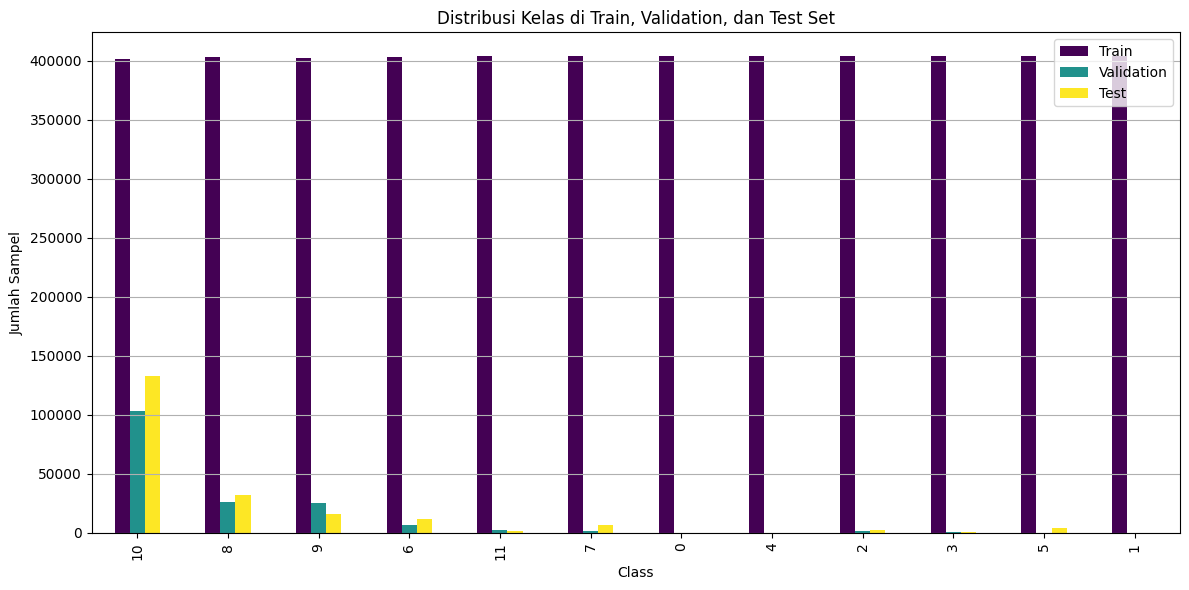

In [24]:
from collections import Counter
import matplotlib.pyplot as plt

# ✅ Hitung distribusi label
train_counts = Counter(y_train_resampled)
val_counts = Counter(y_val)
test_counts = Counter(y_test)

# ✅ Gabungkan ke dalam 1 DataFrame untuk plotting
import pandas as pd

df_split = pd.DataFrame({
    'Train': dict(train_counts),
    'Validation': dict(val_counts),
    'Test': dict(test_counts)
}).fillna(0).astype(int)

# ✅ Plot distribusi per kelas
df_split.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Distribusi Kelas di Train, Validation, dan Test Set')
plt.xlabel('Class')
plt.ylabel('Jumlah Sampel')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

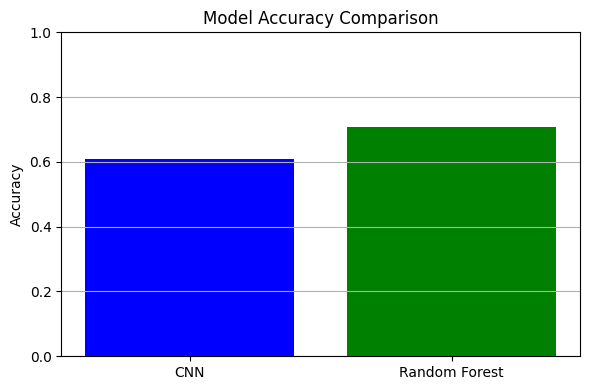

In [25]:
from sklearn.metrics import accuracy_score

acc_cnn = accuracy_score(all_labels, all_preds)
acc_rf = accuracy_score(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
plt.bar(['CNN', 'Random Forest'], [acc_cnn, acc_rf], color=['blue', 'green'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

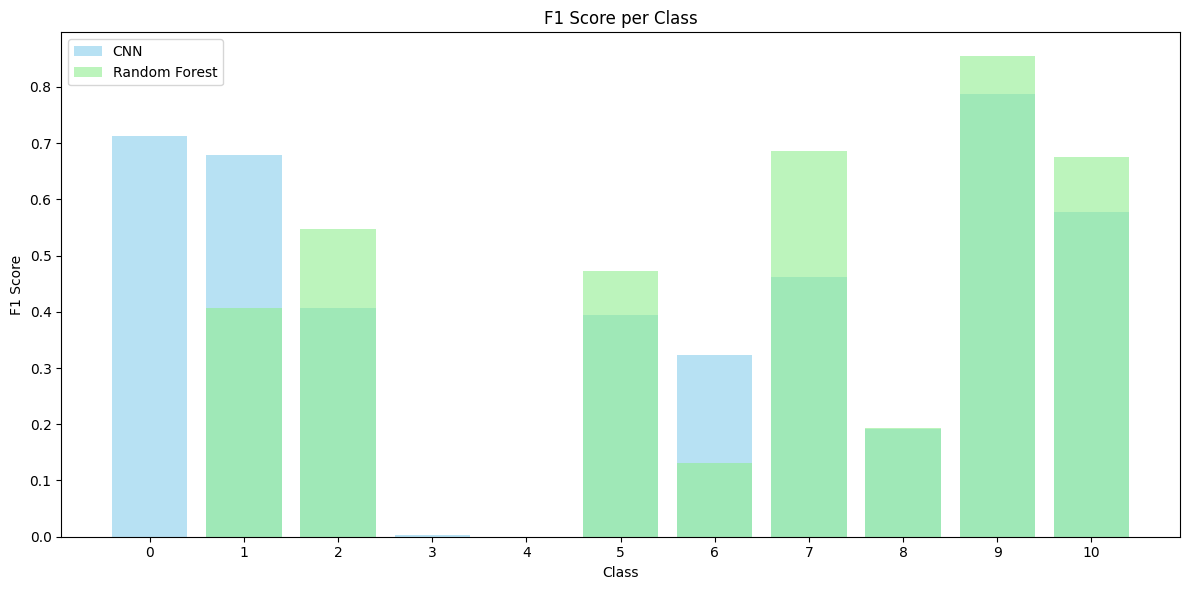

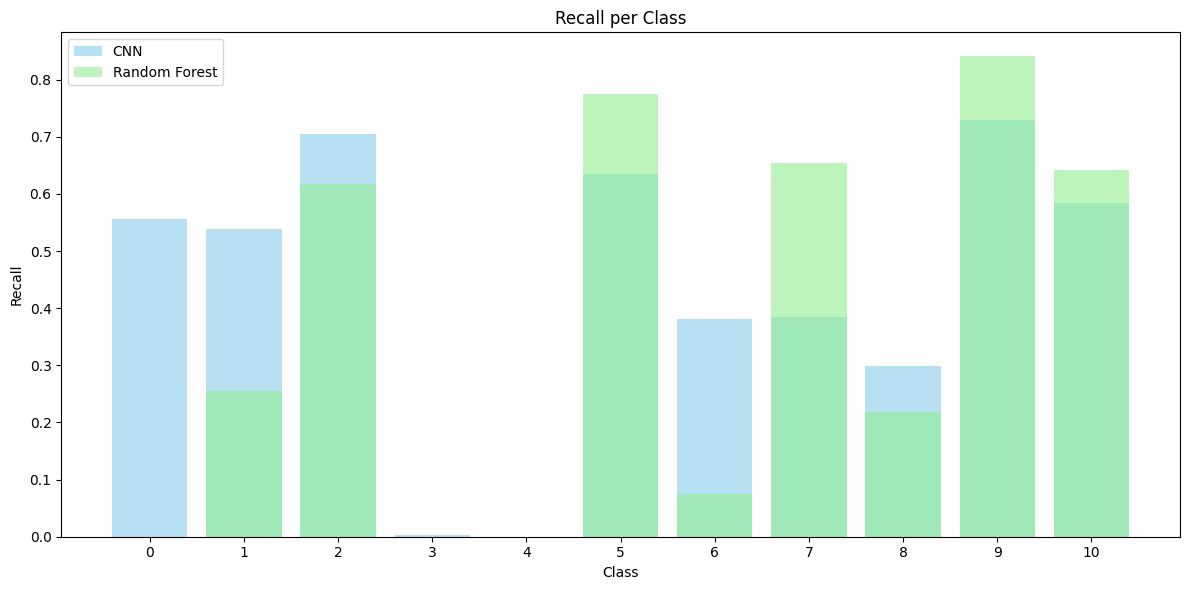

In [26]:
import numpy as np
from sklearn.metrics import f1_score, recall_score

# CNN
f1_cnn = f1_score(all_labels, all_preds, average=None)
recall_cnn = recall_score(all_labels, all_preds, average=None)

# RF
f1_rf = f1_score(y_test, y_pred_rf, average=None)
recall_rf = recall_score(y_test, y_pred_rf, average=None)

classes = list(range(len(f1_cnn)))  # atau len(set(y_test))

# 🔹 F1-score per class
plt.figure(figsize=(12, 6))
plt.bar(classes, f1_cnn, alpha=0.6, label='CNN', color='skyblue')
plt.bar(classes, f1_rf, alpha=0.6, label='Random Forest', color='lightgreen')
plt.xticks(classes)
plt.xlabel('Class')
plt.ylabel('F1 Score')
plt.title('F1 Score per Class')
plt.legend()
plt.tight_layout()
plt.show()

# 🔹 Recall per class
plt.figure(figsize=(12, 6))
plt.bar(classes, recall_cnn, alpha=0.6, label='CNN', color='skyblue')
plt.bar(classes, recall_rf, alpha=0.6, label='Random Forest', color='lightgreen')
plt.xticks(classes)
plt.xlabel('Class')
plt.ylabel('Recall')
plt.title('Recall per Class')
plt.legend()
plt.tight_layout()
plt.show()

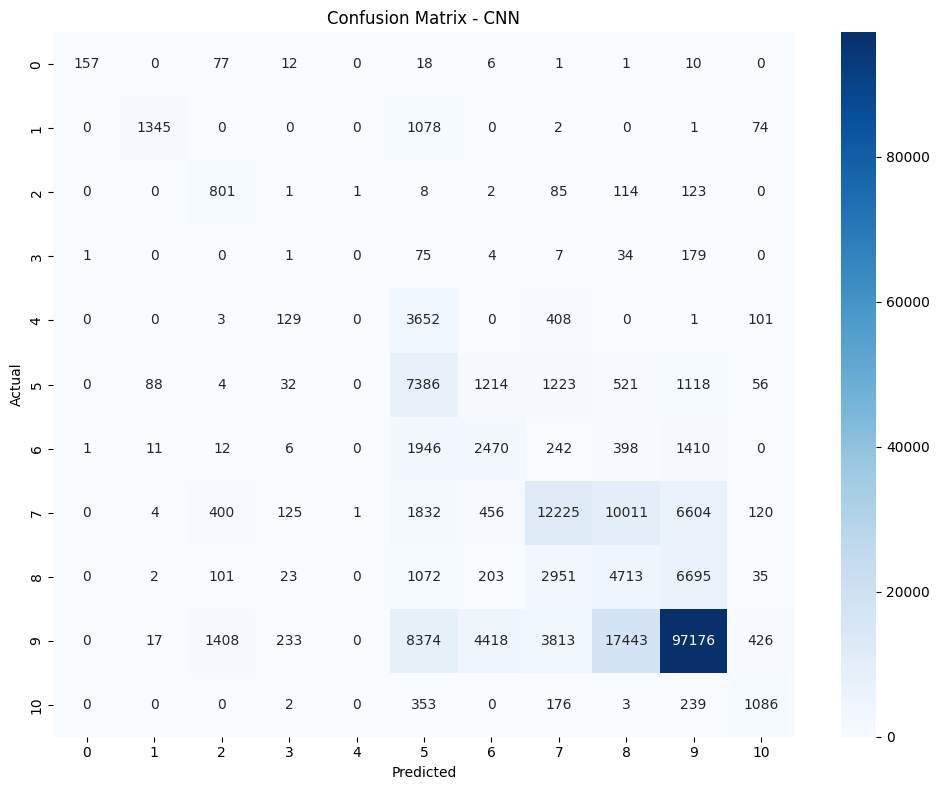

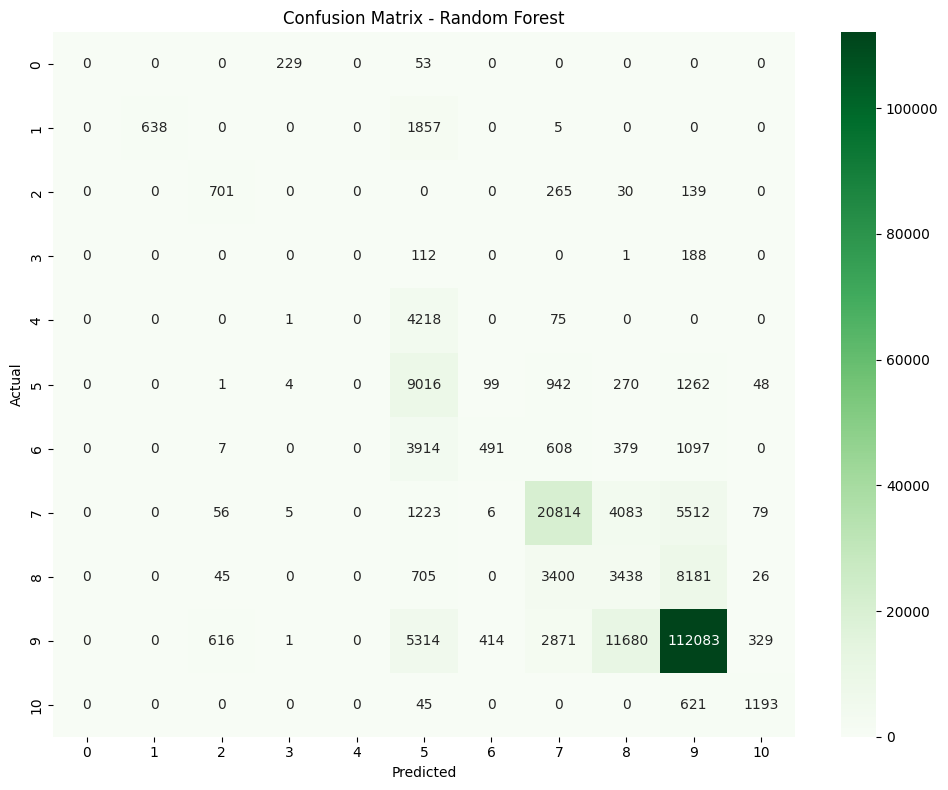

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 🔹 Confusion Matrix CNN
cm_cnn = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 🔹 Confusion Matrix RF
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()